# 데이터 처리

In [1]:
import os, torch
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"  # Arrange GPU devices starting from 0
os.environ["CUDA_VISIBLE_DEVICES"]= "4"  # Set the GPU 2 to use
torch.set_num_threads(16)
# torch.cuda.set_per_process_memory_fraction(0.8, device=None)

In [2]:
# import preprocessing
# import model
import pandas as pd
import json
import numpy as np
from scipy.interpolate import interp1d
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.interpolate import interp1d
import torch.nn.functional as F
import tensorflow as tf
import tensorflow_addons as tfa
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score

import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
tf.random.set_seed(42)


/usr/local/lib/python3.8/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
/usr/local/lib/python3.8/dist-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.11.0 and strictly below 2.14.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.8.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're usin

In [3]:
# CSV 파일 읽기
df_loaded = pd.read_csv('ecg_data.csv')

# JSON 문자열을 dictionary로 변환하고, 리스트를 다시 numpy 배열로 복원
def list_to_numpy(d):
    return {k: np.array(v, dtype=np.float32) for k, v in d.items()}

df_loaded['WaveForm'] = df_loaded['WaveForm'].apply(json.loads)
df_loaded['WaveForm'] = df_loaded['WaveForm'].apply(list_to_numpy)

# 확인
# df = preprocessing.p()
df_loaded['Vent'] = df_loaded['Vent'].replace('1->0', '1')
df = df_loaded

## 1) CMP

In [4]:
cmp = df[df['CMP'] == 1]
non_cmp = df[df['CMP'] == 0]

cmp = cmp[['PatientID','AcquisitionDate','CMP_date','WaveForm','ProcessedWaveForm']]
# 각 검사별로 cmp 발병 후 몇 개월 지난 시점의 검사인지 정의
import pandas as pd
def convert_to_datetime(val):
    try:
        return pd.to_datetime(val, errors='raise')
    except (ValueError, TypeError):
        return val


cmp['AcquisitionDate'] = pd.to_datetime(cmp['AcquisitionDate'], errors='coerce')
cmp['CMP_date'] = pd.to_datetime(cmp['CMP_date'], errors='coerce')

cmp['AcquisitionDate'] = cmp['AcquisitionDate'].apply(convert_to_datetime)
cmp['CMP_date'] = cmp['CMP_date'].apply(convert_to_datetime)

duration = []
for i in range(len(cmp)):
    duration.append((cmp['AcquisitionDate'].iloc[i] - cmp['CMP_date'].iloc[i]).days/30)

cmp['Duration'] = duration
cmp = cmp[((cmp['Duration'] < 120)& (cmp['Duration'] >0))|(cmp['Duration']< -12)]
cmp
label=[]
for i in range(len(cmp)):
    if (cmp['Duration'].iloc[i] < 120)& (cmp['Duration'].iloc[i] >0):
        label.append(1)
    elif (cmp['Duration'].iloc[i]< -12):
        label.append(0)
cmp['Label'] = label
cmp['Label'].value_counts()
non_cmp['Label'] = [0]*len(non_cmp)
non_cmp
tot_df = pd.concat((cmp,non_cmp))

# Tabular 추가
cmp40_18y = pd.read_excel('DMD outcome data 240829 for SPSS_Song0915.xlsx')[['ID','CMP40_18y','WC bound age']]
cmp40_18y['CMP40_18y'] = cmp40_18y['CMP40_18y'].fillna(0)
cmp40_18y = pd.merge(tot_df, cmp40_18y, on='ID', how = 'left')
cmp40_18y['WC_Bound'] = (cmp40_18y['Age'] >= cmp40_18y['WC bound age']).astype(int)
#### Case 1 - cmp 발병이든 비발병이든 18살 이후면 노상관
tot_df = cmp40_18y

## 2) Death

In [ ]:
### CMP 걸리지 않고 사망한 환자 제외
final_data = df
dead_with_no_cmp = final_data[(final_data['Death'] == 1) & (final_data['CMP'] == 0)].PatientID.unique()
# final_data = final_data[~final_data['PatientID'].isin(dead_with_no_cmp)]

len(dead_with_no_cmp)
cmp = df[df['CMP'] == 1]
non_cmp = df[df['CMP'] == 0]
len(non_cmp)
cmp = cmp[['PatientID','Age','AcquisitionDate','CMP_date','WaveForm','Death','Death date','ProcessedWaveForm','Gender', 'scoliosis OP', 'Vent',
       # 'amiodarone', 'Ivabradine', 'carvedilol', 'other betablocker','digoxin', 'Entresto']]
           'Arrhythmia', 'BB', 'ARB ', 'ACEi']]
# 각 검사별로 cmp 발병 후 몇 개월 지난 시점의 검사인지 정의
import pandas as pd
def convert_to_datetime(val):
    try:
        return pd.to_datetime(val, errors='raise')
    except (ValueError, TypeError):
        return val


cmp['AcquisitionDate'] = pd.to_datetime(cmp['AcquisitionDate'], errors='coerce')
cmp['CMP_date'] = pd.to_datetime(cmp['CMP_date'], errors='coerce')
cmp['Death date'] = pd.to_datetime(cmp['Death date'], errors='coerce')

cmp['AcquisitionDate'] = cmp['AcquisitionDate'].apply(convert_to_datetime)
cmp['CMP_date'] = cmp['CMP_date'].apply(convert_to_datetime)
cmp['Death date'] = cmp['Death date'].apply(convert_to_datetime)

duration = []
for i in range(len(cmp)):
    duration.append((cmp['AcquisitionDate'].iloc[i] - cmp['CMP_date'].iloc[i]).days/30)

cmp['Duration'] = duration
cmp_dead = cmp[cmp['Death'] == 1]
cmp_live = cmp[cmp['Death'] == 0]
death_duration = []
for i in range(len(cmp_dead)):
    death_duration.append((cmp_dead['Death date'].iloc[i] - cmp_dead['CMP_date'].iloc[i]).days/30)

cmp_dead['Death Duration'] = death_duration
cmp_dead
cmp_dead = cmp_dead[(cmp_dead['Death Duration']< 120) & (cmp_dead['Duration']< 12) &  (cmp_dead['Duration']> -12)]
cmp_dead
cmp_live = cmp_live[(cmp_live['Duration']< 12) &  (cmp_live['Duration']> -12)]
cmp_live
cmp_dead['Label'] =[1]*len(cmp_dead)
cmp_live['Label'] = [0]*len(cmp_live)
tot_df = pd.concat((cmp_dead,cmp_live), ignore_index=True)

# Tabular 추가
cmp40_18y = pd.read_excel('DMD outcome data 240829 for SPSS_Song0915.xlsx')[['ID','CMP40_18y','WC bound age']]
cmp40_18y['CMP40_18y'] = cmp40_18y['CMP40_18y'].fillna(0)
cmp40_18y = pd.merge(tot_df, cmp40_18y, on='ID', how = 'left')
cmp40_18y['WC_Bound'] = (cmp40_18y['Age'] >= cmp40_18y['WC bound age']).astype(int)
#### Case 1 - cmp 발병이든 비발병이든 18살 이후면 노상관
tot_df = cmp40_18y

## 3) HF Hosp

In [31]:
### CMP 걸리지 않고 사망한 환자 제외
final_data = df
final_data.columns
cmp = df[df['CMP'] == 1]
non_cmp = df[df['CMP'] == 0]
### CMP 걸리지 않고 사망한 환자 제외
final_data = df
dead_with_no_cmp = final_data[(final_data['CMP'] == 1) & (final_data['HF Hosp'] == 0)].PatientID.unique()
# final_data = final_data[~final_data['PatientID'].isin(dead_with_no_cmp)]

len(dead_with_no_cmp)
cmp = cmp[['PatientID','Age','AcquisitionDate','CMP_date','WaveForm','HF Hosp','Hosp_date','ProcessedWaveForm','Gender', 'scoliosis OP', 'Vent','Death date','Death or HF Hosp',
       # 'amiodarone', 'Ivabradine', 'carvedilol', 'other betablocker','digoxin', 'Entresto']]
           'Arrhythmia', 'BB', 'ARB ', 'ACEi', 'ID']]
cmp.columns
# 각 검사별로 cmp 발병 후 몇 개월 지난 시점의 검사인지 정의
import pandas as pd
def convert_to_datetime(val):
    try:
        return pd.to_datetime(val, errors='raise')
    except (ValueError, TypeError):
        return val


cmp['AcquisitionDate'] = pd.to_datetime(cmp['AcquisitionDate'], errors='coerce')
cmp['CMP_date'] = pd.to_datetime(cmp['CMP_date'], errors='coerce')
cmp['Hosp_date'] = pd.to_datetime(cmp['Hosp_date'], errors='coerce')
cmp['Death date'] = pd.to_datetime(cmp['Death date'], errors='coerce')

cmp['AcquisitionDate'] = cmp['AcquisitionDate'].apply(convert_to_datetime)
cmp['CMP_date'] = cmp['CMP_date'].apply(convert_to_datetime)
cmp['Hosp_date'] = cmp['Hosp_date'].apply(convert_to_datetime)
cmp['Death date'] = cmp['Death date'].apply(convert_to_datetime)

duration = []
for i in range(len(cmp)):
    duration.append((cmp['AcquisitionDate'].iloc[i] - cmp['CMP_date'].iloc[i]).days/30)

cmp['Duration'] = duration
cmp_dead = cmp[cmp['HF Hosp'] == 1]
cmp_live = cmp[cmp['HF Hosp'] == 0]
death_duration = []
for i in range(len(cmp_dead)):
    death_duration.append((cmp_dead['Hosp_date'].iloc[i] - cmp_dead['CMP_date'].iloc[i]).days/30)

cmp_dead['Hosp Duration'] = death_duration
cmp_dead
cmp_dead = cmp_dead[(cmp_dead['Hosp Duration']< 120) & (cmp_dead['Duration']< 12) &  (cmp_dead['Duration']> -12)]
cmp_dead
cmp_live = cmp_live[(cmp_live['Duration']< 12) &  (cmp_live['Duration']> -12)]
cmp_live
cmp_dead['Label'] =[1]*len(cmp_dead)
cmp_live['Label'] = [0]*len(cmp_live)
tot_df = pd.concat((cmp_dead,cmp_live), ignore_index=True)

cmp40_18y = pd.read_excel('DMD outcome data 240829 for SPSS_Song0915.xlsx')[['ID','CMP40_18y','WC bound age']]
cmp40_18y['CMP40_18y'] = cmp40_18y['CMP40_18y'].fillna(0)
cmp40_18y = pd.merge(tot_df, cmp40_18y, on='ID', how = 'left')
age8_12 = cmp40_18y[(cmp40_18y['Age'] >=10) & (cmp40_18y['Age'] <14)]
# 측정 당시 wc bound 면 1, 아니면 0
age8_12['WC_Bound'] = (age8_12['Age'] >= age8_12['WC bound age']).astype(int)
# age8_12.rename(columns={'CMP40_18y':'Label'}, inplace=True)
tot_df = age8_12

## 4) Death | HF Hosp

In [ ]:
### CMP 걸리지 않고 사망한 환자 제외
final_data = df
### CMP 걸리지 않고 사망한 환자 제외
final_data = df
dead_with_no_cmp = final_data[(final_data['Death or HF Hosp'] == 1) & (final_data['CMP'] == 0)].PatientID.unique()
# final_data = final_data[~final_data['PatientID'].isin(dead_with_no_cmp)]

print(len(dead_with_no_cmp))
cmp = final_data[final_data['CMP'] == 1]
non_cmp = final_data[final_data['CMP'] == 0]
print(len(cmp))
print(len(non_cmp))
cmp = cmp[['PatientID','Age','AcquisitionDate','CMP_date','WaveForm','HF Hosp','Hosp_date','ProcessedWaveForm','Gender', 'scoliosis OP', 'Vent','Death date','Death or HF Hosp',
       # 'amiodarone', 'Ivabradine', 'carvedilol', 'other betablocker','digoxin', 'Entresto']]
           'Arrhythmia', 'BB', 'ARB ', 'ACEi']]
# 각 검사별로 cmp 발병 후 몇 개월 지난 시점의 검사인지 정의
import pandas as pd
def convert_to_datetime(val):
    try:
        return pd.to_datetime(val, errors='raise')
    except (ValueError, TypeError):
        return val


cmp['AcquisitionDate'] = pd.to_datetime(cmp['AcquisitionDate'], errors='coerce')
cmp['CMP_date'] = pd.to_datetime(cmp['CMP_date'], errors='coerce')
cmp['Hosp_date'] = pd.to_datetime(cmp['Hosp_date'], errors='coerce')
cmp['Death date'] = pd.to_datetime(cmp['Death date'], errors='coerce')

cmp['AcquisitionDate'] = cmp['AcquisitionDate'].apply(convert_to_datetime)
cmp['CMP_date'] = cmp['CMP_date'].apply(convert_to_datetime)
cmp['Hosp_date'] = cmp['Hosp_date'].apply(convert_to_datetime)
cmp['Death date'] = cmp['Death date'].apply(convert_to_datetime)

duration = []
for i in range(len(cmp)):
    duration.append((cmp['AcquisitionDate'].iloc[i] - cmp['CMP_date'].iloc[i]).days/30)

cmp['Duration'] = duration
cmp_dead = cmp[cmp['Death or HF Hosp'] == 1]
cmp_live = cmp[cmp['Death or HF Hosp'] == 0]
print(len(cmp_dead))
print(len(cmp_live))
# 두 열 중 더 이른 날짜를 선택하고 NaN 처리
cmp_dead['HF_Death_date'] = cmp_dead.apply(lambda row: min(row['Hosp_date'], row['Death date']) if pd.notna(row['Hosp_date']) and pd.notna(row['Death date']) else (row['Hosp_date'] if pd.notna(row['Hosp_date']) else row['Death date']), axis=1)

death_duration = []
for i in range(len(cmp_dead)):
    death_duration.append((cmp_dead['HF_Death_date'].iloc[i] - cmp_dead['CMP_date'].iloc[i]).days/30)

cmp_dead['Hosp Duration'] = death_duration
cmp_dead
cmp_dead = cmp_dead[(cmp_dead['Hosp Duration']< 120) & (cmp_dead['Duration']< 6) &  (cmp_dead['Duration']> -6)]
cmp_dead
cmp_live = cmp_live[(cmp_live['Duration']< 6) &  (cmp_live['Duration']> -6)]
cmp_live
cmp_dead['Label'] =[1]*len(cmp_dead)
cmp_live['Label'] = [0]*len(cmp_live)
tot_df = pd.concat((cmp_dead,cmp_live), ignore_index=True)


# Tabular 추가
cmp40_18y = pd.read_excel('DMD outcome data 240829 for SPSS_Song0915.xlsx')[['ID','CMP40_18y','WC bound age']]
cmp40_18y['CMP40_18y'] = cmp40_18y['CMP40_18y'].fillna(0)
cmp40_18y = pd.merge(tot_df, cmp40_18y, on='ID', how = 'left')
cmp40_18y['WC_Bound'] = (cmp40_18y['Age'] >= cmp40_18y['WC bound age']).astype(int)
#### Case 1 - cmp 발병이든 비발병이든 18살 이후면 노상관
tot_df = cmp40_18y

## 5) Early Sever CMP

In [19]:
cmp40_18y = pd.read_excel('DMD outcome data 240829 for SPSS_Song0915.xlsx')[['ID','CMP40_18y','WC bound age']]
cmp40_18y['CMP40_18y'] = cmp40_18y['CMP40_18y'].fillna(0)
cmp40_18y = pd.merge(df, cmp40_18y, on='ID', how = 'left')
age8_12 = cmp40_18y[(cmp40_18y['Age'] >=10) & (cmp40_18y['Age'] <14)]
# 측정 당시 wc bound 면 1, 아니면 0
age8_12['WC_Bound'] = (age8_12['Age'] >= age8_12['WC bound age']).astype(int)
age8_12.rename(columns={'CMP40_18y':'Label'}, inplace=True)
tot_df = age8_12


In [20]:
tot_df['Label'].value_counts()

0.0    664
1.0    173
Name: Label, dtype: int64

# Train, test

In [6]:
def preprocess_data(df):
    data_list = []
    for i in range(len(df)):
        d = df['WaveForm'].iloc[i]
        if len(d) > 12:
            keys_to_exclude = {'V3R', 'V4R', 'V7'}
            filtered_dict = {key: value for key, value in d.items() if key not in keys_to_exclude}
        else:
            filtered_dict = d

        single_data = np.vstack(filtered_dict.values())
        if single_data.shape != (12, 5000):
            array_2500 = single_data
            x_2500 = np.linspace(0, 12, single_data.shape[1])
            x_5000 = np.linspace(0, 12, 5000)
            linear_interpolator = interp1d(x_2500, array_2500, kind='linear')
            array_5000 = linear_interpolator(x_5000)
            data_list.append(array_5000.T)  # (12, 5000) -> (5000, 12)
        else:
            data_list.append(single_data.T)  # (12, 5000) -> (5000, 12)
    return np.array(data_list)

In [7]:
tot_df['ACEi'] = tot_df['ACEi'].fillna(0)
tot_df['scoliosis OP'] = tot_df['scoliosis OP'].fillna(0)
tot_df['Vent'] = tot_df['Vent'].fillna(0)
tot_df['Arrhythmia'] = tot_df['Arrhythmia'].fillna(0)
tot_df['BB'] = tot_df['BB'].fillna(0)
tot_df['ARB '] = tot_df['ARB '].fillna(0)

In [8]:
def preprocess_and_split_data(tot_df, feature_list):
    # 고유 PatientID를 기준으로 데이터 분리
    unique_patient_ids = tot_df['PatientID'].unique()
    train_ids, test_ids = train_test_split(unique_patient_ids, test_size=0.1, random_state=42)

    train_df = tot_df[tot_df['PatientID'].isin(train_ids)]
    test_df = tot_df[tot_df['PatientID'].isin(test_ids)]

    # ECG 데이터 전처리 수행
    X_train = preprocess_data(train_df)  # 사용자가 정의한 ECG 데이터 전처리 함수
    X_test = preprocess_data(test_df)
    y_train = np.array(train_df['Label'])
    y_test = np.array(test_df['Label'])

    # ECG 데이터 정규화 (각 채널별로)
    scaler = StandardScaler()
    
    # 학습 데이터 스케일링
    X_train = X_train.reshape(-1, X_train.shape[-1])  # 2D로 변경
    X_train = scaler.fit_transform(X_train)
    X_train = X_train.reshape(-1, 5000, 12)  # 다시 3D로 변경 (12, 5000 -> 5000, 12)

    # 테스트 데이터 스케일링
    X_test = X_test.reshape(-1, X_test.shape[-1])
    X_test = scaler.transform(X_test)
    X_test = X_test.reshape(-1, 5000, 12)



    # 탭 데이터 (메타데이터) 전처리
    X_train_tabular = np.array(train_df[feature_list]).astype(np.float32)
    X_test_tabular = np.array(test_df[feature_list]).astype(np.float32)

    return X_train, X_train_tabular, y_train, X_test, X_test_tabular, y_test

# 모델

In [13]:
def set_seed(seed=42):
    import random
    import tensorflow as tf
    # Python 랜덤 시드 설정
    random.seed(seed)
    # NumPy 랜덤 시드 설정
    np.random.seed(seed)
    # TensorFlow 랜덤 시드 설정
    tf.random.set_seed(seed)
set_seed(42)

In [14]:
model_results = []

# 결과를 저장하는 함수
def save_model_results(model_name, auroc, acc, batch_size = None,patch_size=None, hidden_size=None, depth=None, num_heads=None, mlp_dim=None, epochs=None, feature_num = None):
    model_results.append([
        model_name, 
        auroc, 
        acc, 
        batch_size if batch_size is not None else np.nan, 
        patch_size if patch_size is not None else np.nan, 
        hidden_size if hidden_size is not None else np.nan, 
        depth if depth is not None else np.nan, 
        num_heads if num_heads is not None else np.nan, 
        mlp_dim if mlp_dim is not None else np.nan,
        epochs if epochs is not None else np.nan,
        feature_num if feature_num is not None else np.nan
    ])


In [15]:
feature_list = ['WC_Bound']#,'scoliosis OP']# 'BB', 'ARB ', 'ACEi']#, 'scoliosis OP', 'Vent', 'Arrhythmia']

## 1) CNN(예전)

In [40]:
def CNN_MODEL(tot_df,batch_size, epochs):
    X_train, X_train_tabular, y_train, X_test, X_test_tabular, y_test = preprocess_and_split_data(tot_df,feature_list)

    # Convert numpy arrays to PyTorch tensors and move to device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Here, we expect the input to be (5000, 12), so we need to transpose it to (12, 5000)
    # Use permute(0, 2, 1) to swap the second and third dimensions
    X_train = torch.tensor(X_train, dtype=torch.float32).permute(0, 2, 1).to(device)  # (batch_size, 12, 5000)
    y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
    X_test = torch.tensor(X_test, dtype=torch.float32).permute(0, 2, 1).to(device)  # (batch_size, 12, 5000)
    y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

    # PyTorch CNN Model Definition
    class CNNModel(nn.Module):
        def __init__(self):
            super(CNNModel, self).__init__()
            self.conv1 = nn.Conv1d(in_channels=12, out_channels=64, kernel_size=5, padding=2)
            self.bn1 = nn.BatchNorm1d(64)
            self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, padding=2)
            self.bn2 = nn.BatchNorm1d(128)
            self.conv3 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
            self.bn3 = nn.BatchNorm1d(256)
            self.pool = nn.MaxPool1d(kernel_size=2, stride=2, padding=0)
            self.fc1 = nn.Linear(256 * 625, 256)
            self.fc2 = nn.Linear(256, 1)
            self.dropout = nn.Dropout(0.5)
            self.relu = nn.ReLU()
            
        def forward(self, x):
            x = self.pool(self.relu(self.bn1(self.conv1(x))))
            x = self.pool(self.relu(self.bn2(self.conv2(x))))
            x = self.pool(self.relu(self.bn3(self.conv3(x))))
            x = x.view(-1, 256 * 625)
            x = self.dropout(self.relu(self.fc1(x)))
            x = self.fc2(x).squeeze(-1)
            return x

    # Initialize the model, define the loss function and the optimizer
    model = CNNModel().to(device)
    criterion = nn.BCEWithLogitsLoss()  # Use BCEWithLogitsLoss for binary classification
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training loop
    num_epochs = epochs
    batch_size = batch_size

    # Create DataLoader
    train_data = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)

    for epoch in range(num_epochs):
        model.train()  # Set the model to training mode

        train_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(inputs)
            # outputs = outputs.squeeze()  # Remove extra dimensions
            loss = criterion(outputs, labels)
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)

        train_loss = train_loss / len(train_loader.dataset)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch + 1}/{num_epochs}], Train Loss: {train_loss:.4f}')

    print("Training complete.")

    # Evaluate on test data
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test)
        test_outputs = test_outputs.squeeze()  # Remove extra dimensions

    # Convert logits to probabilities and then to binary predictions
    test_probabilities = torch.sigmoid(test_outputs)
    test_predictions = torch.round(test_probabilities)

    # Convert PyTorch tensors to numpy arrays
    test_predictions_np = test_predictions.cpu().numpy()
    y_test_np = y_test.cpu().numpy()

    # Compute accuracy
    test_accuracy = accuracy_score(y_test_np, test_predictions_np)

    # Compute ROC AUC score
    test_roc_auc = roc_auc_score(y_test_np, test_probabilities.cpu().numpy())

    print(f'Test Accuracy: {test_accuracy:.4f}')
    print(f'Test ROC AUC Score: {test_roc_auc:.4f}')
    save_model_results('cnn_1', test_accuracy, test_roc_auc,batch_size = batch_size, epochs = epochs)

    

In [ ]:
CNN_MODEL(tot_df, batch_size = 32, epochs = 100)#, waveform = 'WaveForm')

## 2) CNN + Tabular(예전)

In [62]:
def CNN_MODEL_TABULAR_ADDED(tot_df, batch_size, epochs):
    # 데이터 분리 및 전처리
    X_train, X_train_tabular, y_train, X_test, X_test_tabular, y_test = preprocess_and_split_data(tot_df,feature_list)
    
    # Convert numpy arrays to PyTorch tensors and move to device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # ECG 데이터가 (5000, 12) 형식이므로 permute로 차원 변환 (batch_size, 12, 5000)
    X_train = torch.tensor(X_train, dtype=torch.float32).permute(0, 2, 1).to(device)
    X_train_tabular = torch.tensor(X_train_tabular, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
    X_test = torch.tensor(X_test, dtype=torch.float32).permute(0, 2, 1).to(device)
    X_test_tabular = torch.tensor(X_test_tabular, dtype=torch.float32).to(device)
    y_test = torch.tensor(y_test, dtype=torch.float32).to(device)
    
        # PyTorch CNN Model Definition
    class CNNModel(nn.Module):
        def __init__(self, num_tabular_features):
            super(CNNModel, self).__init__()
            self.conv1 = nn.Conv1d(in_channels=12, out_channels=64, kernel_size=5, padding=2)
            self.bn1 = nn.BatchNorm1d(64)
            self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, padding=2)
            self.bn2 = nn.BatchNorm1d(128)
            self.conv3 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
            self.bn3 = nn.BatchNorm1d(256)
            self.pool = nn.MaxPool1d(kernel_size=2, stride=2, padding=0)
            self.fc1 = nn.Linear(256 * 625, 256)
            self.fc2 = nn.Linear(256 + num_tabular_features, 1)  # Combining CNN output and tabular data
            self.dropout = nn.Dropout(0.5)
            self.relu = nn.ReLU()
            
        def forward(self, x, tabular_data):
            x = self.pool(self.relu(self.bn1(self.conv1(x))))
            x = self.pool(self.relu(self.bn2(self.conv2(x))))
            x = self.pool(self.relu(self.bn3(self.conv3(x))))
            x = x.view(-1, 256 * 625)
            x = self.dropout(self.relu(self.fc1(x)))
            combined = torch.cat((x, tabular_data), dim=1)  # Concatenate CNN output and tabular data
            x = self.fc2(combined).squeeze(-1)
            return x

    # Initialize the model, define the loss function and the optimizer
    model = CNNModel(num_tabular_features=X_train_tabular.shape[1]).to(device)  # Dynamically get the number of tabular features
    criterion = nn.BCEWithLogitsLoss()  # Use BCEWithLogitsLoss for binary classification
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training loop
    num_epochs = epochs
    batch_size = batch_size

    # Create DataLoader
    train_data = torch.utils.data.TensorDataset(X_train, X_train_tabular, y_train)
    train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)

    for epoch in range(num_epochs):
        model.train()  # Set the model to training mode

        train_loss = 0.0
        for inputs, tabular_data, labels in train_loader:
            inputs, tabular_data, labels = inputs.to(device), tabular_data.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(inputs, tabular_data)
            loss = criterion(outputs, labels)
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)

        train_loss = train_loss / len(train_loader.dataset)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch + 1}/{num_epochs}], Train Loss: {train_loss:.4f}')

    print("Training complete.")

    # Evaluate on test data
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test, X_test_tabular)
        test_outputs = test_outputs.squeeze()  # Remove extra dimensions

    # Convert logits to probabilities and then to binary predictions
    test_probabilities = torch.sigmoid(test_outputs)
    test_predictions = torch.round(test_probabilities)

    # Convert PyTorch tensors to numpy arrays
    test_predictions_np = test_predictions.cpu().numpy()
    y_test_np = y_test.cpu().numpy()

    # Compute accuracy
    test_accuracy = accuracy_score(y_test_np, test_predictions_np)

    # Compute ROC AUC score
    test_roc_auc = roc_auc_score(y_test_np, test_probabilities.cpu().numpy())

    print(f'Test Accuracy: {test_accuracy:.4f}')
    print(f'Test ROC AUC Score: {test_roc_auc:.4f}')
    save_model_results('cnn_tab_1', test_accuracy, test_roc_auc,batch_size = batch_size, epochs = epochs, feature_num = X_train_tabular.shape[1])

In [63]:
# tabular_features = ['scoliosis OP', 'Vent','Arrhythmia', 'BB', 'ARB ', 'ACEi']
batch_size = 32
epochs = 100
CNN_MODEL_TABULAR_ADDED(tot_df, batch_size, epochs)

Epoch [10/100], Train Loss: 0.2293
Epoch [20/100], Train Loss: 0.0861
Epoch [30/100], Train Loss: 0.0567
Epoch [40/100], Train Loss: 0.1055
Epoch [50/100], Train Loss: 0.0608
Epoch [60/100], Train Loss: 0.0641
Epoch [70/100], Train Loss: 0.0410
Epoch [80/100], Train Loss: 0.0308
Epoch [90/100], Train Loss: 0.0364
Epoch [100/100], Train Loss: 0.0372
Training complete.
Test Accuracy: 0.8022
Test ROC AUC Score: 0.5947


## CNN(New)

In [42]:
import os
import random
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

# 시드 설정 함수
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # GPU 관련 비결정성 방지 설정
    if tf.config.list_physical_devices('GPU'):
        tf.config.experimental.enable_op_determinism()

# ECG 1D Convolutional feature extraction
def build_ecg_model(input_shape):
    ecg_input = layers.Input(shape=input_shape, name='ecg_input')
    x = layers.Conv1D(64, kernel_size=3, activation='relu')(ecg_input)
    x = layers.Conv1D(128, kernel_size=3, activation='relu')(x)
    x = layers.GlobalAveragePooling1D()(x)
    ecg_output = layers.Dense(64, activation='relu')(x)
    output = layers.Dense(1, activation='sigmoid')(ecg_output)
    return models.Model(inputs=ecg_input, outputs=output, name='ecg_model')

# 평가 함수
def evaluate_model(model, X_test, y_test):
    y_pred_proba = model.predict(X_test)
    y_pred = (y_pred_proba > 0.5).astype(int)
    auroc = roc_auc_score(y_test, y_pred_proba)
    accuracy = accuracy_score(y_test, y_pred)
    return auroc, accuracy

# 모델 학습 및 평가를 epoch마다 수행하는 함수
def compile_and_fit_model_with_evaluation(model, X_train, y_train, X_test, y_test, epochs=10, batch_size=32):
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        # 학습 수행
        model.fit(X_train, y_train, batch_size=batch_size, verbose=0)

        # 평가 수행
        auroc, accuracy = evaluate_model(model, X_test, y_test)
        print(f"Test AUROC: {auroc:.4f}, Test Accuracy: {accuracy:.4f}")

# 전체 파이프라인 실행 함수
def run_pipeline_cnn_2(tot_df, model_name = 'cnn_2', epochs=10, batch_size=32):
    # 시드 설정
    set_seeds(42)
    
    X_train, X_train_tabular, y_train, X_test, X_test_tabular, y_test = preprocess_and_split_data(tot_df,feature_list)
    

    # 모델 및 데이터 설정
    ecg_shape = (5000, 12)

    # 모델 생성
    model = build_ecg_model(ecg_shape)
    
    # 모델 학습 및 epoch마다 평가
    compile_and_fit_model_with_evaluation(model, X_train, y_train, X_test, y_test, epochs=epochs, batch_size=batch_size)
    auroc, acc = evaluate_model(model, X_test, y_test)
    print(f"Test AUROC: {auroc:.4f}, Test Accuracy: {acc:.4f}")
    save_model_results(model_name, epochs = epochs, batch_size = batch_size, auroc = auroc, acc = acc)
    
# 예시: tot_df는 데이터프레임을 전달합니다.
run_pipeline_cnn_2(tot_df, epochs=10, model_name = 'cnn_2', batch_size=32)


Epoch 1/10
Test AUROC: 0.7801, Test Accuracy: 0.8571
Epoch 2/10
Test AUROC: 0.7761, Test Accuracy: 0.8571
Epoch 3/10
Test AUROC: 0.7821, Test Accuracy: 0.8571
Epoch 4/10
Test AUROC: 0.7742, Test Accuracy: 0.8571
Epoch 5/10
Test AUROC: 0.7623, Test Accuracy: 0.8571
Epoch 6/10
Test AUROC: 0.7554, Test Accuracy: 0.8571
Epoch 7/10
Test AUROC: 0.7495, Test Accuracy: 0.8681
Epoch 8/10
Test AUROC: 0.7387, Test Accuracy: 0.8681
Epoch 9/10
Test AUROC: 0.7357, Test Accuracy: 0.8571
Epoch 10/10
Test AUROC: 0.7258, Test Accuracy: 0.8571
Test AUROC: 0.7258, Test Accuracy: 0.8571


## CNN+Tabular(New)

In [64]:
import os
import random
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models



# 시드 설정 함수
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # GPU 관련 비결정성 방지 설정
    if tf.config.list_physical_devices('GPU'):
        tf.config.experimental.enable_op_determinism()


# ECG 1D Convolutional feature extraction
def build_ecg_model(input_shape):
    ecg_input = layers.Input(shape=input_shape, name='ecg_input')
    x = layers.Conv1D(64, kernel_size=3, activation='relu')(ecg_input)
    x = layers.Conv1D(128, kernel_size=3, activation='relu')(x)
    x = layers.GlobalAveragePooling1D()(x)
    ecg_output = layers.Dense(64, activation='relu')(x)
    output = layers.Dense(1, activation='sigmoid')(ecg_output)
    return models.Model(inputs=ecg_input, outputs=output, name='ecg_model')

# Tabular data feature extraction
def build_tabular_model(input_shape):
    tabular_input = layers.Input(shape=(input_shape,), name='tabular_input')
    x = layers.Dense(64, activation='relu')(tabular_input)
    x = layers.Dense(32, activation='relu')(x)
    tabular_output = layers.Dense(16, activation='relu')(x)
    return models.Model(inputs=tabular_input, outputs=tabular_output, name='tabular_model')

# Fusion and classification
def build_fusion_model(ecg_shape, tabular_shape):
    ecg_model = build_ecg_model(ecg_shape)
    tabular_model = build_tabular_model(tabular_shape)
    combined = layers.concatenate([ecg_model.output, tabular_model.output])
    x = layers.Dense(128, activation='relu')(combined)
    x = layers.Dense(64, activation='relu')(x)
    output = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs=[ecg_model.input, tabular_model.input], outputs=output)

# 평가 함수
def evaluate_model(model, X_test, X_test_tabular, y_test):
    y_pred_proba = model.predict([X_test, X_test_tabular])
    y_pred = (y_pred_proba > 0.5).astype(int)
    auroc = roc_auc_score(y_test, y_pred_proba)
    accuracy = accuracy_score(y_test, y_pred)
    return auroc, accuracy

# 모델 학습 및 평가를 epoch마다 수행하는 함수
def compile_and_fit_model_with_evaluation(model, X_train, X_train_tabular, y_train, X_test, X_test_tabular, y_test, epochs=10, batch_size=32):
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        # 학습 수행
        model.fit([X_train, X_train_tabular], y_train, batch_size=batch_size, verbose=0)

        # 평가 수행
        auroc, accuracy = evaluate_model(model, X_test, X_test_tabular, y_test)
        print(f"Test AUROC: {auroc:.4f}, Test Accuracy: {accuracy:.4f}")

# 전체 파이프라인 실행 함수
def run_pipeline_cnn_tab2(tot_df, epochs=10, model_name='cnn_tab2', batch_size=32):
    # 시드 설정
    set_seeds(42)
    
    X_train, X_train_tabular, y_train, X_test, X_test_tabular, y_test = preprocess_and_split_data(tot_df,feature_list)
    # 모델 및 데이터 설정
    ecg_shape = (5000, 12)
    tabular_shape = X_train_tabular.shape[-1]

    # 모델 생성
    model = build_fusion_model(ecg_shape, tabular_shape)
    model._name = model_name
    # 모델 학습 및 epoch마다 평가
    compile_and_fit_model_with_evaluation(model, X_train, X_train_tabular, y_train, X_test, X_test_tabular, y_test, epochs=epochs, batch_size=batch_size)
    auroc, acc = evaluate_model(model, X_test, X_test_tabular, y_test)
    print(f"Test AUROC: {auroc:.4f}, Test Accuracy: {acc:.4f}")
    save_model_results(model_name, auroc, acc, epochs = epochs, batch_size = batch_size, feature_num = X_train_tabular.shape[1])
# 예시: tot_df는 데이터프레임을 전달합니다.
run_pipeline_cnn_tab2(tot_df, epochs=10,model_name='cnn_tab2', batch_size=32)


Epoch 1/10
Test AUROC: 0.4576, Test Accuracy: 0.8571
Epoch 2/10
Test AUROC: 0.6188, Test Accuracy: 0.8571
Epoch 3/10
Test AUROC: 0.7032, Test Accuracy: 0.8571
Epoch 4/10
Test AUROC: 0.6943, Test Accuracy: 0.8571
Epoch 5/10
Test AUROC: 0.6958, Test Accuracy: 0.8571
Epoch 6/10
Test AUROC: 0.6884, Test Accuracy: 0.8571
Epoch 7/10
Test AUROC: 0.6834, Test Accuracy: 0.8571
Epoch 8/10
Test AUROC: 0.6839, Test Accuracy: 0.8571
Epoch 9/10
Test AUROC: 0.6879, Test Accuracy: 0.8571
Epoch 10/10
Test AUROC: 0.6893, Test Accuracy: 0.8571
Test AUROC: 0.6893, Test Accuracy: 0.8571


## 3) ViT

In [16]:
def create_tf_dataset(X, y, shuffle, batch_size):
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(X))
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
    return dataset

class ViTEmbeddings(tf.keras.layers.Layer):
    def __init__(self, patch_size, hidden_size, dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.hidden_size = hidden_size
        self.patch_embeddings = tf.keras.layers.Conv1D(filters=hidden_size, kernel_size=patch_size, strides=patch_size)
        self.dropout = tf.keras.layers.Dropout(rate=dropout)

    def build(self, input_shape):
        self.cls_token = self.add_weight(shape=(1, 1, self.hidden_size), trainable=True, name="cls_token")
        num_patches = input_shape[1] // self.patch_size
        self.position_embeddings = self.add_weight(
            shape=(1, num_patches + 1, self.hidden_size), trainable=True, name="position_embeddings"
        )

    def call(self, inputs: tf.Tensor, training: bool = False) -> tf.Tensor:
        inputs_shape = tf.shape(inputs)  
        embeddings = self.patch_embeddings(inputs, training=training)
        cls_tokens = tf.repeat(self.cls_token, repeats=inputs_shape[0], axis=0)
        embeddings = tf.concat((cls_tokens, embeddings), axis=1)
        embeddings = embeddings + self.position_embeddings
        embeddings = self.dropout(embeddings, training=training)
        return embeddings

class MLP(tf.keras.layers.Layer):
    def __init__(self, mlp_dim, out_dim=None, activation="gelu", dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        self.mlp_dim = mlp_dim
        self.out_dim = out_dim
        self.activation = activation
        self.dropout_rate = dropout

    def build(self, input_shape):
        self.dense1 = tf.keras.layers.Dense(self.mlp_dim)
        self.activation1 = tf.keras.layers.Activation(self.activation)
        self.dropout = tf.keras.layers.Dropout(self.dropout_rate)
        self.dense2 = tf.keras.layers.Dense(input_shape[-1] if self.out_dim is None else self.out_dim)

    def call(self, inputs: tf.Tensor, training: bool = False):
        x = self.dense1(inputs)
        x = self.activation1(x)
        x = self.dropout(x, training=training)
        x = self.dense2(x)
        x = self.dropout(x, training=training)
        return x
    
class Block(tf.keras.layers.Layer):
    def __init__(
        self,
        num_heads,
        attention_dim,
        attention_bias,
        mlp_dim,
        attention_dropout=0.0,
        sd_survival_probability=1.0,
        activation="gelu",
        dropout=0.0,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.norm_before = tf.keras.layers.LayerNormalization()
        self.attn = tf.keras.layers.MultiHeadAttention(
            num_heads,
            attention_dim // num_heads,
            use_bias=attention_bias,
            dropout=attention_dropout,
        )
        self.stochastic_depth = tfa.layers.StochasticDepth(sd_survival_probability)
        self.norm_after = tf.keras.layers.LayerNormalization()
        self.mlp = MLP(mlp_dim=mlp_dim, activation=activation, dropout=dropout)

    def call(self, inputs, training=False):
        x = self.norm_before(inputs, training=training)
        x = self.attn(x, x, training=training)
        x = self.stochastic_depth([inputs, x], training=training)
        x2 = self.norm_after(x, training=training)
        x2 = self.mlp(x2, training=training)
        return self.stochastic_depth([x, x2], training=training)

    def get_attention_scores(self, inputs):
        # 여기서 attention scores를 계산하여 반환합니다.
        # x는 norm_before을 통과한 값이어야 하므로, 이를 활용해 attention을 계산합니다.
        norm_inputs = self.norm_before(inputs, training=False)
        _, attention_scores = self.attn(norm_inputs, norm_inputs, return_attention_scores=True)
        return attention_scores


class VisionTransformer(tf.keras.Model):
    def __init__(
        self,
        patch_size,
        hidden_size,
        depth,
        num_heads,
        mlp_dim,
        num_classes,
        dropout=0.0,
        sd_survival_probability=1.0,
        attention_bias=False,
        attention_dropout=0.0,
        *args,
        **kwargs,
    ):
        super().__init__(*args, **kwargs)

        self.embeddings = ViTEmbeddings(patch_size, hidden_size, dropout)
        sd = tf.linspace(1.0, sd_survival_probability, depth)
        self.blocks = [
            Block(
                num_heads,
                attention_dim=hidden_size,
                attention_bias=attention_bias,
                attention_dropout=attention_dropout,
                mlp_dim=mlp_dim,
                sd_survival_probability=(sd[i].numpy().item()),
                dropout=dropout,
            )
            for i in range(depth)
        ]

        self.norm = tf.keras.layers.LayerNormalization()

        self.head = tf.keras.layers.Dense(num_classes)

    def call(self, inputs: tf.Tensor, training: bool = False) -> tf.Tensor:
        x = self.embeddings(inputs, training=training)
        for block in self.blocks:
            x = block(x, training=training)
        x = self.norm(x)
        x = x[:, 0]  # take only cls_token
        return self.head(x)

    def get_last_selfattention(self, inputs: tf.Tensor):
        x = self.embeddings(inputs, training=False)
        for block in self.blocks[:-1]:
            x = block(x, training=False)
        return self.blocks[-1].get_attention_scores(x)


def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def run_vit_training(df, batch_size=32, epochs=20, test_size=0.1, random_state=42, 
                     patch_size=10, hidden_size=768, depth=12, num_heads=12, mlp_dim=256):
    # 시드 설정
    set_seeds(random_state)
    
    # GPU 사용 시 결정적 동작 설정
    if tf.config.list_physical_devices('GPU'):
        tf.config.experimental.enable_op_determinism()

    X_train, X_train_tabular, y_train, X_test, X_test_tabular, y_test = preprocess_and_split_data(tot_df,feature_list)

    # 텐서플로우 데이터셋 생성
    train_ds = create_tf_dataset(X_train, y_train, shuffle=True, batch_size=batch_size)
    val_ds = create_tf_dataset(X_test, y_test, shuffle=False, batch_size=batch_size)

    # ViT 모델 생성
    vit = VisionTransformer(
        patch_size=patch_size,
        hidden_size=hidden_size,
        depth=depth,
        num_heads=num_heads,
        mlp_dim=mlp_dim,
        num_classes=1,
        sd_survival_probability=0.9,
    )

    # 모델 컴파일 및 학습
    optimizer = tf.keras.optimizers.Adam(0.0001)
    loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)
    metrics = [tf.keras.metrics.AUC(from_logits=True, name="roc_auc"),
               tf.keras.metrics.BinaryAccuracy(name="accuracy")]
    vit.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    cbs = [tf.keras.callbacks.ModelCheckpoint("vit_best/", monitor="val_roc_auc", save_best_only=True, save_weights_only=True)]

    vit.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=cbs)

    # 최종 테스트 결과 평가
    test_loss, test_roc_auc, test_accuracy = vit.evaluate(val_ds, verbose=1)

    # ROC-AUC 곡선을 위한 예측
    y_pred = vit.predict(val_ds)
    y_pred = tf.nn.sigmoid(y_pred).numpy().flatten()  # logits을 확률로 변환

    # ROC 곡선 계산
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)

    # ROC 곡선 그리기
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()
    
    save_model_results('ViT', test_roc_auc, test_accuracy, batch_size = batch_size, patch_size = patch_size, hidden_size = hidden_size, depth = depth,num_heads = num_heads, mlp_dim = mlp_dim, epochs = epochs)
    return vit, {"Test Loss": test_loss, "Test ROC AUC": test_roc_auc, "Test Accuracy": test_accuracy}


2024-10-21 00:49:34.843061: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-21 00:49:45.583665: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1525] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 45927 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:c5:00.0, compute capability: 8.6


Epoch 1/20


2024-10-21 00:49:58.926768: I tensorflow/stream_executor/cuda/cuda_dnn.cc:368] Loaded cuDNN version 8302
2024-10-21 00:50:07.059636: I tensorflow/stream_executor/cuda/cuda_blas.cc:1786] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


407/407 [==============================] - 41s 53ms/step - loss: 0.5722 - roc_auc: 0.7558 - accuracy: 0.7196 - val_loss: 0.4248 - val_roc_auc: 0.8720 - val_accuracy: 0.7971
Epoch 2/20
407/407 [==============================] - 20s 49ms/step - loss: 0.4361 - roc_auc: 0.8614 - accuracy: 0.7959 - val_loss: 0.4700 - val_roc_auc: 0.8631 - val_accuracy: 0.7159
Epoch 3/20
407/407 [==============================] - 21s 51ms/step - loss: 0.3877 - roc_auc: 0.8936 - accuracy: 0.8186 - val_loss: 0.4939 - val_roc_auc: 0.8560 - val_accuracy: 0.8464
Epoch 4/20
407/407 [==============================] - 20s 48ms/step - loss: 0.3818 - roc_auc: 0.8963 - accuracy: 0.8208 - val_loss: 0.4062 - val_roc_auc: 0.8819 - val_accuracy: 0.8609
Epoch 5/20
407/407 [==============================] - 19s 48ms/step - loss: 0.3578 - roc_auc: 0.9089 - accuracy: 0.8328 - val_loss: 0.5056 - val_roc_auc: 0.8615 - val_accuracy: 0.8377
Epoch 6/20
407/407 [==============================] - 19s 48ms/step - loss: 0.3484 - roc_au

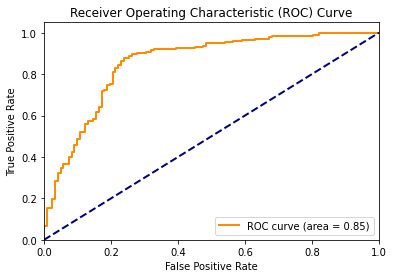

{'Test Loss': 0.7259603142738342, 'Test ROC AUC': 0.845309853553772, 'Test Accuracy': 0.8173912763595581}


In [18]:
import random
vit_patch_size=20
vit_hidden_size=512
vit_depth=12
vit_num_heads=12
vit_mlp_dim=512
vit, results = run_vit_training(tot_df, batch_size=8, epochs=20, test_size=0.1, 
                                        patch_size = vit_patch_size,
                                        hidden_size = vit_hidden_size,
                                        depth = vit_depth,
                                        num_heads = vit_num_heads,
                                        mlp_dim = vit_mlp_dim)
print(results)

Epoch 1/20
47/47 [==============================] - 7s 71ms/step - loss: 0.5356 - roc_auc: 0.5963 - accuracy: 0.7815 - val_loss: 0.3951 - val_roc_auc: 0.6898 - val_accuracy: 0.8571
Epoch 2/20
47/47 [==============================] - 2s 42ms/step - loss: 0.5107 - roc_auc: 0.6144 - accuracy: 0.7869 - val_loss: 0.4087 - val_roc_auc: 0.5922 - val_accuracy: 0.8571
Epoch 3/20
47/47 [==============================] - 2s 39ms/step - loss: 0.4799 - roc_auc: 0.6946 - accuracy: 0.7882 - val_loss: 0.4091 - val_roc_auc: 0.6524 - val_accuracy: 0.8462
Epoch 4/20
47/47 [==============================] - 2s 38ms/step - loss: 0.4709 - roc_auc: 0.7175 - accuracy: 0.7855 - val_loss: 0.4490 - val_roc_auc: 0.7027 - val_accuracy: 0.8352
Epoch 5/20
47/47 [==============================] - 2s 40ms/step - loss: 0.4673 - roc_auc: 0.7231 - accuracy: 0.8016 - val_loss: 0.4768 - val_roc_auc: 0.5868 - val_accuracy: 0.8462
Epoch 6/20
47/47 [==============================] - 2s 39ms/step - loss: 0.4478 - roc_auc: 0.75

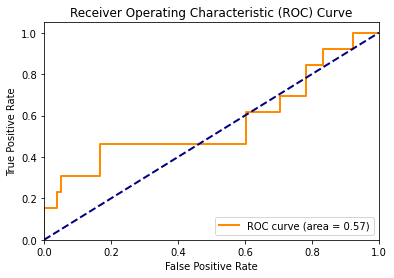

{'Test Loss': 0.6252268552780151, 'Test ROC AUC': 0.5591715574264526, 'Test Accuracy': 0.8571428656578064}
Epoch 1/20
47/47 [==============================] - 14s 147ms/step - loss: 0.7698 - roc_auc: 0.5389 - accuracy: 0.7453 - val_loss: 0.4200 - val_roc_auc: 0.6341 - val_accuracy: 0.8571
Epoch 2/20
47/47 [==============================] - 5s 107ms/step - loss: 0.5186 - roc_auc: 0.6279 - accuracy: 0.7895 - val_loss: 0.4662 - val_roc_auc: 0.5597 - val_accuracy: 0.8462
Epoch 3/20
47/47 [==============================] - 4s 90ms/step - loss: 0.5003 - roc_auc: 0.6475 - accuracy: 0.7936 - val_loss: 0.4071 - val_roc_auc: 0.6529 - val_accuracy: 0.8352
Epoch 4/20
47/47 [==============================] - 4s 93ms/step - loss: 0.4858 - roc_auc: 0.7047 - accuracy: 0.7895 - val_loss: 0.4696 - val_roc_auc: 0.5848 - val_accuracy: 0.8462
Epoch 5/20
47/47 [==============================] - 5s 109ms/step - loss: 0.4684 - roc_auc: 0.7200 - accuracy: 0.7936 - val_loss: 0.5259 - val_roc_auc: 0.4926 - val_a

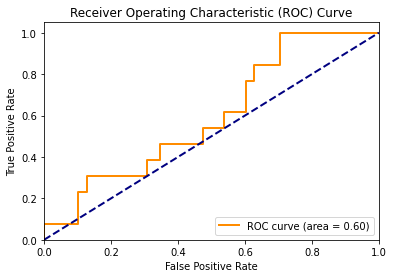

{'Test Loss': 0.8759976029396057, 'Test ROC AUC': 0.5340237021446228, 'Test Accuracy': 0.7802197933197021}
Epoch 1/20
94/94 [==============================] - 12s 57ms/step - loss: 0.5583 - roc_auc: 0.5506 - accuracy: 0.7708 - val_loss: 0.4176 - val_roc_auc: 0.5957 - val_accuracy: 0.8571
Epoch 2/20
94/94 [==============================] - 4s 40ms/step - loss: 0.5065 - roc_auc: 0.6425 - accuracy: 0.7802 - val_loss: 0.5813 - val_roc_auc: 0.5552 - val_accuracy: 0.7692
Epoch 3/20
94/94 [==============================] - 4s 45ms/step - loss: 0.4892 - roc_auc: 0.6832 - accuracy: 0.7882 - val_loss: 0.4711 - val_roc_auc: 0.5340 - val_accuracy: 0.8571
Epoch 4/20
94/94 [==============================] - 3s 35ms/step - loss: 0.4703 - roc_auc: 0.7153 - accuracy: 0.7922 - val_loss: 0.4594 - val_roc_auc: 0.6021 - val_accuracy: 0.8571
Epoch 5/20
94/94 [==============================] - 3s 36ms/step - loss: 0.4716 - roc_auc: 0.7205 - accuracy: 0.7895 - val_loss: 0.5728 - val_roc_auc: 0.5523 - val_accu

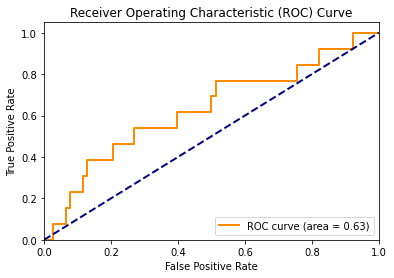

{'Test Loss': 0.899865984916687, 'Test ROC AUC': 0.6178501844406128, 'Test Accuracy': 0.8131868243217468}


In [45]:
vit_patch_size=10
vit_hidden_size=128
vit_depth=6
vit_num_heads=6
vit_mlp_dim=128
vit, results = run_vit_training(tot_df, batch_size=16, epochs=20, test_size=0.1, 
                                        patch_size = vit_patch_size,
                                        hidden_size = vit_hidden_size,
                                        depth = vit_depth,
                                        num_heads = vit_num_heads,
                                        mlp_dim = vit_mlp_dim)
print(results)

vit_patch_size=20
vit_hidden_size=512
vit_depth=12
vit_num_heads=12
vit_mlp_dim=512
vit, results = run_vit_training(tot_df, batch_size=16, epochs=20, test_size=0.1, 
                                        patch_size = vit_patch_size,
                                        hidden_size = vit_hidden_size,
                                        depth = vit_depth,
                                        num_heads = vit_num_heads,
                                        mlp_dim = vit_mlp_dim)
print(results)

vit_patch_size=20
vit_hidden_size=256
vit_depth=12
vit_num_heads=12
vit_mlp_dim=128
vit, results = run_vit_training(tot_df, batch_size=8, epochs=20, test_size=0.1, 
                                        patch_size = vit_patch_size,
                                        hidden_size = vit_hidden_size,
                                        depth = vit_depth,
                                        num_heads = vit_num_heads,
                                        mlp_dim = vit_mlp_dim)
print(results)

Epoch 1/20
94/94 [==============================] - 14s 74ms/step - loss: 0.6461 - roc_auc: 0.5391 - accuracy: 0.7601 - val_loss: 0.4410 - val_roc_auc: 0.6893 - val_accuracy: 0.8571
Epoch 2/20
94/94 [==============================] - 5s 53ms/step - loss: 0.5316 - roc_auc: 0.6176 - accuracy: 0.7788 - val_loss: 0.5269 - val_roc_auc: 0.6445 - val_accuracy: 0.8462
Epoch 3/20
94/94 [==============================] - 4s 47ms/step - loss: 0.5206 - roc_auc: 0.6405 - accuracy: 0.7761 - val_loss: 0.3983 - val_roc_auc: 0.6474 - val_accuracy: 0.8571
Epoch 4/20
94/94 [==============================] - 4s 47ms/step - loss: 0.4856 - roc_auc: 0.6868 - accuracy: 0.7909 - val_loss: 0.4101 - val_roc_auc: 0.6583 - val_accuracy: 0.8352
Epoch 5/20
94/94 [==============================] - 5s 53ms/step - loss: 0.5058 - roc_auc: 0.6724 - accuracy: 0.7842 - val_loss: 0.4626 - val_roc_auc: 0.5843 - val_accuracy: 0.8571
Epoch 6/20
94/94 [==============================] - 4s 46ms/step - loss: 0.4863 - roc_auc: 0.6

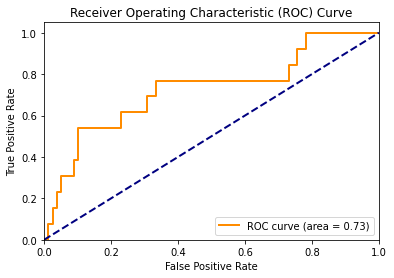

{'Test Loss': 0.5804321765899658, 'Test ROC AUC': 0.7218934893608093, 'Test Accuracy': 0.8351648449897766}


In [46]:
vit_patch_size=20
vit_hidden_size=512
vit_depth=12
vit_num_heads=12
vit_mlp_dim=512
vit, results = run_vit_training(tot_df, batch_size=8, epochs=20, test_size=0.1, 
                                        patch_size = vit_patch_size,
                                        hidden_size = vit_hidden_size,
                                        depth = vit_depth,
                                        num_heads = vit_num_heads,
                                        mlp_dim = vit_mlp_dim)
print(results)

## 4) ViT + Tabular

In [65]:
# Tabular 데이터 처리를 위한 MLP (Dense layer)
def build_tabular_model(input_shape):
    tabular_input = tf.keras.layers.Input(shape=(input_shape,), name='tabular_input')
    x = tf.keras.layers.Dense(64, activation='relu')(tabular_input)
    x = tf.keras.layers.Dense(32, activation='relu')(x)
    tabular_output = tf.keras.layers.Dense(16, activation='relu')(x)
    return tf.keras.Model(inputs=tabular_input, outputs=tabular_output, name='tabular_model')

class VisionTransformerWithTabular(tf.keras.Model):
    def __init__(
        self,
        patch_size,
        hidden_size,
        depth,
        num_heads,
        mlp_dim,
        num_classes,
        tabular_input_shape,  # Tabular 데이터 크기 추가
        dropout=0.0,
        sd_survival_probability=1.0,
        attention_bias=False,
        attention_dropout=0.0,
        *args,
        **kwargs,
    ):
        super().__init__(*args, **kwargs)

        # Vision Transformer 부분
        self.embeddings = ViTEmbeddings(patch_size, hidden_size, dropout)
        sd = tf.linspace(1.0, sd_survival_probability, depth)
        self.blocks = [
            Block(
                num_heads,
                attention_dim=hidden_size,
                attention_bias=attention_bias,
                attention_dropout=attention_dropout,
                mlp_dim=mlp_dim,
                sd_survival_probability=(sd[i].numpy().item()),
                dropout=dropout,
            )
            for i in range(depth)
        ]

        self.norm = tf.keras.layers.LayerNormalization()

        # Tabular 데이터 처리 모델
        self.tabular_model = build_tabular_model(tabular_input_shape)

        # Classification Head (두 feature 결합 후)
        self.head = tf.keras.layers.Dense(num_classes)

    def call(self, inputs: tf.Tensor, training: bool = False) -> tf.Tensor:
        # inputs는 (ecg_inputs, tabular_inputs)의 튜플로 전달됩니다.
        ecg_inputs, tabular_inputs = inputs
        
        # ViT 처리 (ECG)
        x = self.embeddings(ecg_inputs, training=training)
        for block in self.blocks:
            x = block(x, training=training)
        x = self.norm(x)
        vit_output = x[:, 0]  # cls_token

        # Tabular 데이터 처리
        tabular_output = self.tabular_model(tabular_inputs)

        # Feature 결합
        combined = tf.concat([vit_output, tabular_output], axis=-1)

        # 최종 예측
        return self.head(combined)

import numpy as np
import tensorflow as tf
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# TensorFlow 데이터셋 생성 함수 수정
def create_tf_dataset(X_ecg, X_tabular, y, shuffle, batch_size):
    # ECG와 Tabular 데이터를 따로 처리 후 결합
    ecg_ds = tf.data.Dataset.from_tensor_slices(X_ecg)
    tabular_ds = tf.data.Dataset.from_tensor_slices(X_tabular)
    labels_ds = tf.data.Dataset.from_tensor_slices(y)
    
    # 두 입력 데이터를 zip하여 하나의 데이터셋으로 결합
    dataset = tf.data.Dataset.zip(((ecg_ds, tabular_ds), labels_ds))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(X_ecg))
    
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
    
    return dataset

# 모델 학습 및 평가 함수
def run_vit_with_tabular_training(tot_df,
                                  batch_size=32, epochs=20, random_state=42, 
                                  patch_size=10, hidden_size=768, depth=12, num_heads=12, mlp_dim=256):
    
    # 시드 설정
    np.random.seed(random_state)
    tf.random.set_seed(random_state)

    X_train_ecg, X_train_tabular, y_train, X_test_ecg, X_test_tabular, y_test = preprocess_and_split_data(tot_df,feature_list)

    # 텐서플로우 데이터셋 생성
    train_ds = create_tf_dataset(X_train_ecg, X_train_tabular, y_train, shuffle=True, batch_size=batch_size)
    val_ds = create_tf_dataset(X_test_ecg, X_test_tabular, y_test, shuffle=False, batch_size=batch_size)

    # ViT with Tabular 모델 생성 (이미 정의된 VisionTransformerWithTabular 사용)
    vit_tabular = VisionTransformerWithTabular(
        patch_size=patch_size,
        hidden_size=hidden_size,
        depth=depth,
        num_heads=num_heads,
        mlp_dim=mlp_dim,
        num_classes=1,
        tabular_input_shape=X_train_tabular.shape[1],  # Tabular 데이터 크기 전달
        sd_survival_probability=0.9,
    )

    # 모델 컴파일 및 학습
    optimizer = tf.keras.optimizers.Adam(0.0001)
    loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)
    metrics = [tf.keras.metrics.AUC(from_logits=True, name="roc_auc"),
               tf.keras.metrics.BinaryAccuracy(name="accuracy")]
    vit_tabular.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    cbs = [tf.keras.callbacks.ModelCheckpoint("vit_best/", monitor="val_roc_auc", save_best_only=True, save_weights_only=True)]

    history = vit_tabular.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=cbs)

    # 최종 테스트 결과 평가
    test_loss, test_roc_auc, test_accuracy = vit_tabular.evaluate(val_ds, verbose=1)

    # ROC-AUC 곡선을 위한 예측
    y_pred = vit_tabular.predict(val_ds)
    y_pred = tf.nn.sigmoid(y_pred).numpy().flatten()

    # ROC 곡선 계산 및 시각화
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()
    save_model_results('ViT_tab', test_roc_auc, test_accuracy, batch_size = batch_size, patch_size = patch_size, hidden_size = hidden_size, depth = depth,num_heads = num_heads, mlp_dim = mlp_dim, epochs = epochs, feature_num = X_train_tabular.shape[1])
    return vit_tabular, history, {"Test Loss": test_loss, "Test ROC AUC": test_roc_auc, "Test Accuracy": test_accuracy}

Epoch 1/20
94/94 [==============================] - 15s 76ms/step - loss: 0.6788 - roc_auc: 0.5005 - accuracy: 0.7534 - val_loss: 0.4618 - val_roc_auc: 0.6040 - val_accuracy: 0.8571
Epoch 2/20
94/94 [==============================] - 5s 53ms/step - loss: 0.5168 - roc_auc: 0.6345 - accuracy: 0.7775 - val_loss: 0.5257 - val_roc_auc: 0.5661 - val_accuracy: 0.8352
Epoch 3/20
94/94 [==============================] - 4s 46ms/step - loss: 0.5145 - roc_auc: 0.6521 - accuracy: 0.7815 - val_loss: 0.4148 - val_roc_auc: 0.5710 - val_accuracy: 0.8571
Epoch 4/20
94/94 [==============================] - 4s 46ms/step - loss: 0.4834 - roc_auc: 0.6904 - accuracy: 0.7842 - val_loss: 0.4298 - val_roc_auc: 0.5794 - val_accuracy: 0.8571
Epoch 5/20
94/94 [==============================] - 5s 55ms/step - loss: 0.5011 - roc_auc: 0.6895 - accuracy: 0.7855 - val_loss: 0.5336 - val_roc_auc: 0.5444 - val_accuracy: 0.8462
Epoch 6/20
94/94 [==============================] - 4s 47ms/step - loss: 0.4588 - roc_auc: 0.7

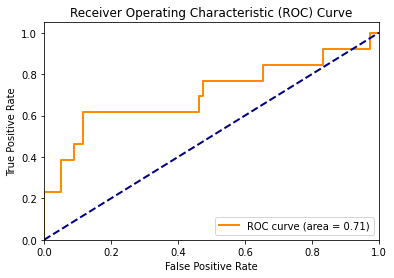

(<__main__.VisionTransformerWithTabular at 0x7f499dd60fd0>,
 {'Test Loss': 0.4300857484340668,
  'Test ROC AUC': 0.6972386837005615,
  'Test Accuracy': 0.8571428656578064})

In [66]:
run_vit_with_tabular_training(tot_df,
                                batch_size = 8,
                                patch_size = 20,
                                hidden_size = 512, mlp_dim=512,
                                depth=12, num_heads=12,
                                random_state = 42,
                                epochs = 20)

Epoch 1/10
94/94 [==============================] - 15s 75ms/step - loss: 0.6788 - roc_auc: 0.5005 - accuracy: 0.7534 - val_loss: 0.4618 - val_roc_auc: 0.6040 - val_accuracy: 0.8571
Epoch 2/10
94/94 [==============================] - 5s 54ms/step - loss: 0.5168 - roc_auc: 0.6345 - accuracy: 0.7775 - val_loss: 0.5257 - val_roc_auc: 0.5661 - val_accuracy: 0.8352
Epoch 3/10
94/94 [==============================] - 4s 47ms/step - loss: 0.5145 - roc_auc: 0.6521 - accuracy: 0.7815 - val_loss: 0.4148 - val_roc_auc: 0.5710 - val_accuracy: 0.8571
Epoch 4/10
94/94 [==============================] - 4s 46ms/step - loss: 0.4834 - roc_auc: 0.6904 - accuracy: 0.7842 - val_loss: 0.4298 - val_roc_auc: 0.5794 - val_accuracy: 0.8571
Epoch 5/10
94/94 [==============================] - 5s 54ms/step - loss: 0.5011 - roc_auc: 0.6895 - accuracy: 0.7855 - val_loss: 0.5336 - val_roc_auc: 0.5444 - val_accuracy: 0.8462
Epoch 6/10
94/94 [==============================] - 4s 47ms/step - loss: 0.4588 - roc_auc: 0.7

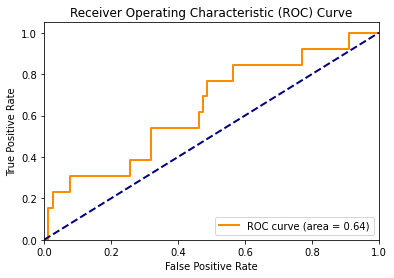

Epoch 1/10
47/47 [==============================] - 13s 130ms/step - loss: 0.8186 - roc_auc: 0.5212 - accuracy: 0.7292 - val_loss: 0.3867 - val_roc_auc: 0.7633 - val_accuracy: 0.8571
Epoch 2/10
47/47 [==============================] - 4s 94ms/step - loss: 0.5662 - roc_auc: 0.5514 - accuracy: 0.7842 - val_loss: 0.4125 - val_roc_auc: 0.6282 - val_accuracy: 0.8571
Epoch 3/10
47/47 [==============================] - 4s 78ms/step - loss: 0.4890 - roc_auc: 0.6663 - accuracy: 0.7882 - val_loss: 0.3973 - val_roc_auc: 0.6696 - val_accuracy: 0.8352
Epoch 4/10
47/47 [==============================] - 4s 78ms/step - loss: 0.4852 - roc_auc: 0.6974 - accuracy: 0.7882 - val_loss: 0.4642 - val_roc_auc: 0.6469 - val_accuracy: 0.8462
Epoch 5/10
47/47 [==============================] - 4s 95ms/step - loss: 0.4853 - roc_auc: 0.6916 - accuracy: 0.7895 - val_loss: 0.4520 - val_roc_auc: 0.5247 - val_accuracy: 0.8462
Epoch 6/10
47/47 [==============================] - 4s 80ms/step - loss: 0.4743 - roc_auc: 0.

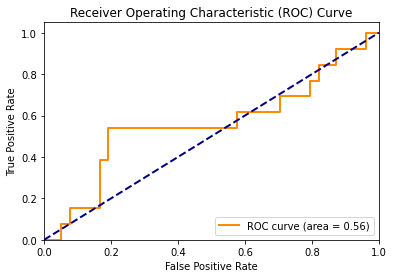

(<__main__.VisionTransformerWithTabular at 0x7f4ae7af85e0>,
 {'Test Loss': 0.49197229743003845,
  'Test ROC AUC': 0.5650888085365295,
  'Test Accuracy': 0.8021978139877319})

In [67]:
run_vit_with_tabular_training(tot_df,
                                batch_size = 8,
                                patch_size = 20,
                                hidden_size = 512, mlp_dim=512,
                                depth=12, num_heads=12,
                                random_state = 42,
                                epochs = 10)

run_vit_with_tabular_training(tot_df,
                                batch_size = 16,
                                patch_size = 20,
                                hidden_size = 512, mlp_dim=512,
                                depth=12, num_heads=12,
                                random_state = 42,
                                epochs = 10)

## 5) LSTM + Tabular
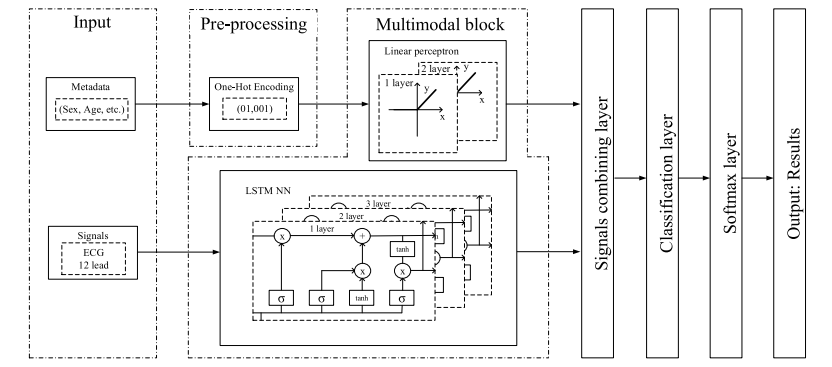

In [68]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score

# 모델 정의 함수
def create_multimodal_ecg_model(metadata_dim, signal_dim, lstm_hidden_size, lstm_layers, output_dim):
    class MultimodalECGModel(nn.Module):
        def __init__(self):
            super(MultimodalECGModel, self).__init__()
            # 메타데이터 처리 레이어
            self.metadata_layer = nn.Sequential(
                nn.Linear(metadata_dim, 64),
                nn.ReLU(),
                nn.Linear(64, 32)
            )

            # ECG 시계열 데이터를 위한 LSTM 레이어
            self.lstm = nn.LSTM(input_size=signal_dim, hidden_size=lstm_hidden_size, 
                                num_layers=lstm_layers, batch_first=True)

            # 다중모달 결합 레이어
            self.combined_layer = nn.Sequential(
                nn.Linear(lstm_hidden_size + 32, 64),
                nn.ReLU(),
                nn.Linear(64, output_dim)
            )

        def forward(self, metadata, signals):
            # 메타데이터 처리
            metadata_out = self.metadata_layer(metadata)

            # ECG 신호 처리
            lstm_out, _ = self.lstm(signals)
            lstm_out = lstm_out[:, -1, :]  # 마지막 LSTM 출력을 사용

            # 결합
            combined = torch.cat((metadata_out, lstm_out), dim=1)
            output = self.combined_layer(combined)

            return output
    
    return MultimodalECGModel()

# 학습 및 평가 함수
def train_multimodal_model(tot_df,
                           signal_dim, lstm_hidden_size, lstm_layers, output_dim,
                           batch_size=16, num_epochs=10, lr=0.001):
    X_train, X_train_tabular, y_train, X_test, X_test_tabular, y_test = preprocess_and_split_data(tot_df,feature_list)
    # 데이터 텐서 변환
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    X_train_tabular_tensor = torch.tensor(X_train_tabular, dtype=torch.float32)
    X_test_tabular_tensor = torch.tensor(X_test_tabular, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    # GPU 사용 설정
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = create_multimodal_ecg_model(len(feature_list), signal_dim, lstm_hidden_size, lstm_layers, output_dim)
    model.to(device)

    # 데이터도 GPU로 이동
    X_train_tensor = X_train_tensor.to(device)
    X_train_tabular_tensor = X_train_tabular_tensor.to(device)
    y_train_tensor = y_train_tensor.to(device)

    X_test_tensor = X_test_tensor.to(device)
    X_test_tabular_tensor = X_test_tabular_tensor.to(device)
    y_test_tensor = y_test_tensor.to(device)

    # 손실 함수 및 옵티마이저 정의
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # 모델 학습 루프
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        correct = 0

        for i in range(0, len(X_train_tensor), batch_size):
            batch_signals = X_train_tensor[i:i+batch_size]
            batch_metadata = X_train_tabular_tensor[i:i+batch_size]
            batch_labels = y_train_tensor[i:i+batch_size]

            # 모델 예측
            optimizer.zero_grad()
            outputs = model(batch_metadata, batch_signals)

            # 손실 계산
            loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            correct += (outputs.argmax(1) == batch_labels).sum().item()

        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss/len(X_train_tensor)}, Accuracy: {correct/len(X_train_tensor)}')

    # 테스트 데이터로 평가
    model.eval()
    with torch.no_grad():
        outputs = model(X_test_tabular_tensor, X_test_tensor)
        test_loss = criterion(outputs, y_test_tensor).item()
        test_accuracy = (outputs.argmax(1) == y_test_tensor).sum().item() / len(y_test_tensor)

        # AUC-ROC 계산
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()  # 클래스 1의 확률을 추출
        auc = roc_auc_score(y_test_tensor.cpu().numpy(), probs)

    print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}, AUC-ROC: {auc}')
    save_model_results('lstm_tab', auc, test_accuracy, epochs = epochs, batch_size = batch_size, feature_num = X_train_tabular.shape[1])

# 사용 예시
# 하이퍼파라미터 설정
# metadata_dim = X_train_tabular.shape[1]  # 메타데이터 차원
signal_dim = 12  # ECG 리드 수
lstm_hidden_size = 64
lstm_layers = 3
output_dim = 2  # 이진 분류

# 모델 학습 및 평가 실행
train_multimodal_model(tot_df, signal_dim, lstm_hidden_size, lstm_layers, output_dim,
                               batch_size=16, num_epochs=10, lr=0.001)


Epoch 1/10, Loss: 0.02983953931740917, Accuracy: 0.774798927613941
Epoch 2/10, Loss: 0.041344887809203715, Accuracy: 0.7855227882037533
Epoch 3/10, Loss: 0.03489515149401596, Accuracy: 0.7855227882037533
Epoch 4/10, Loss: 0.0348043270189385, Accuracy: 0.7855227882037533
Epoch 5/10, Loss: 0.034510777918646866, Accuracy: 0.7855227882037533
Epoch 6/10, Loss: 0.03442480888507322, Accuracy: 0.7855227882037533
Epoch 7/10, Loss: 0.034249361055146595, Accuracy: 0.7855227882037533
Epoch 8/10, Loss: 0.03421622207113629, Accuracy: 0.7855227882037533
Epoch 9/10, Loss: 0.034663063811073355, Accuracy: 0.7855227882037533
Epoch 10/10, Loss: 0.033909076540144134, Accuracy: 0.7855227882037533
Test Loss: 0.41238465905189514, Test Accuracy: 0.8571428571428571, AUC-ROC: 0.6272189349112426


# 모델 전체 결과

In [69]:
df_results = pd.DataFrame(model_results, columns=['Model Name', 'AUROC', 'Accuracy', 'Batch Size', 'Patch Size', 'Hidden Size', 'Depth', 'Num Heads', 'MLP Dim','Epoch','d'])

In [70]:
df_results

,Model Name,AUROC,Accuracy,Batch Size,Patch Size,Hidden Size,Depth,Num Heads,MLP Dim,Epoch,d
0,cnn_1,0.736264,0.579882,32,NaN,NaN,NaN,NaN,NaN,100,NaN
1,cnn_tab_1,0.736264,0.633136,32,NaN,NaN,NaN,NaN,NaN,100,1.0
2,cnn_2,0.725838,0.857143,32,NaN,NaN,NaN,NaN,NaN,10,NaN
3,cnn_tab2,0.687377,0.857143,32,NaN,NaN,NaN,NaN,NaN,10,1.0
4,ViT,0.559172,0.857143,16,10.0,128.0,6.0,6.0,128.0,20,NaN
5,ViT,0.534024,0.780220,16,20.0,512.0,12.0,12.0,512.0,20,NaN
6,ViT,0.617850,0.813187,8,20.0,256.0,12.0,12.0,128.0,20,NaN
7,ViT,0.721893,0.835165,8,20.0,512.0,12.0,12.0,512.0,20,NaN
8,ViT_tab,0.600592,0.813187,8,20.0,512.0,12.0,12.0,512.0,20,1.0
9,ViT_tab,0.620316,0.846154,8,20.0,512.0,12.0,12.0,512.0,10,1.0


: 

In [148]:
tot_df['Label'].value_counts()

1    2390
0    1208
Name: Label, dtype: int64

# 시각화

In [ ]:
def plot_ecg_attention(ecg_data, model, lead_index=11, weights_path='vit_best/'):

    # 배치 차원 추가 (1, 5000, 12)
    input_data = np.expand_dims(ecg_data, axis=0)
    
    # 모델 가중치 로드
    model.load_weights(weights_path)

    # TensorFlow 텐서로 변환
    input_data_tf = tf.convert_to_tensor(input_data, dtype=tf.float32)

    # 모델에서 self-attention 맵을 얻음
    attn = model.get_last_selfattention(input_data_tf)

    # CLS 토큰 관련 attention 스코어 추출
    attn = attn[0, :, 0, 1:]
    
    # Attention 스코어를 5000 샘플로 확장
    attn = tf.transpose(attn, (1, 0))  # (250, 6) -> (6, 250)
    attn = tf.expand_dims(tf.expand_dims(attn, 0), 0)
    attn = tf.image.resize(attn, (1, 5000))[0, 0]
    
    # ECG 데이터와 모든 head의 attention 값 평균
    ecg_data_lead = ecg_data[:, lead_index]  # 선택한 리드의 ECG 데이터
    attn_avg = np.mean(attn, axis=1)  # 모든 head의 attention 값의 평균

    # x 축 좌표 생성
    x = np.linspace(0, len(ecg_data_lead), len(ecg_data_lead))

    # 전체 ECG 데이터를 검정색 라인으로 플롯
    fig, ax = plt.subplots(figsize=(30, 8))
    ax.plot(x, ecg_data_lead, color='black', linewidth=1, label=f'Lead {lead_index + 1}')

    # 컬러맵과 노멀라이제이션 설정
    cmap = plt.get_cmap('Reds')
    norm = Normalize(vmin=np.min(attn_avg), vmax=np.max(attn_avg))

    # 강조할 부분만을 별도로 계산
    points = np.array([x, ecg_data_lead]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    lc = LineCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(attn_avg)  # 평균화된 attn 값에 따라 색상을 설정
    lc.set_linewidth(2)

    # 강조된 부분을 검정색 라인 위에 덮어쓰기
    ax.add_collection(lc)

    # 컬러바 추가
    fig.colorbar(lc, ax=ax, label='Average Attention Score')

    # 그래프 설정
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(ecg_data_lead.min(), ecg_data_lead.max())
    ax.set_title(f'ECG Lead {lead_index + 1} with Highlighted Average Attention')

    plt.show()




#### 시각화 참고

- head 당 attention

In [ ]:



import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

def plot_ecg_attention_per_head(ecg_data, model, head_list =[1,2], lead_list =[1,2], weights_path='vit_best/'):
    # 배치 차원 추가 (1, 5000, 12)
    input_data = np.expand_dims(ecg_data, axis=0)
    
    # 모델 가중치 로드
    model.load_weights(weights_path)

    # TensorFlow 텐서로 변환
    input_data_tf = tf.convert_to_tensor(input_data, dtype=tf.float32)

    # 모델에서 self-attention 맵을 얻음
    attn = model.get_last_selfattention(input_data_tf)

    # CLS 토큰 관련 attention 스코어 추출
    attn = attn[0, :, 0, 1:]  # (num_heads, num_patches)
    
    num_heads = attn.shape[0]
    num_leads = ecg_data.shape[1]

    # Attention 스코어를 5000 샘플로 확장
    attn = tf.transpose(attn, (1, 0))  # (num_patches, num_heads)
    attn = tf.expand_dims(tf.expand_dims(attn, 0), 0)
    attn = tf.image.resize(attn, (1, 5000))[0, 0]  # (5000, num_heads)

    # 그래프 생성
    fig, axes = plt.subplots(num_heads, num_leads, figsize=(5*num_leads, 4*num_heads))
    fig.suptitle("ECG Leads with Attention Scores for Each Head", fontsize=16)

    for head in head_list:
        for lead in lead_list:
            ax = axes[head, lead]
            
            ecg_data_lead = ecg_data[:, lead]
            attn_head = attn[:, head]

            # x 축 좌표 생성
            x = np.linspace(0, len(ecg_data_lead), len(ecg_data_lead))

            # 전체 ECG 데이터를 검정색 라인으로 플롯
            ax.plot(x, ecg_data_lead, color='black', linewidth=1)

            # 컬러맵과 노멀라이제이션 설정
            cmap = plt.get_cmap('Reds')
            norm = Normalize(vmin=np.min(attn_head), vmax=np.max(attn_head))

            # 강조할 부분만을 별도로 계산
            points = np.array([x, ecg_data_lead]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)

            lc = LineCollection(segments, cmap=cmap, norm=norm)
            lc.set_array(attn_head)
            lc.set_linewidth(2)

            # 강조된 부분을 검정색 라인 위에 덮어쓰기
            ax.add_collection(lc)

            # 그래프 설정
            ax.set_xlim(x.min(), x.max())
            ax.set_ylim(ecg_data_lead.min(), ecg_data_lead.max())
            ax.set_title(f'Head {head+1}, Lead {lead+1}')
            ax.set_xticks([])
            ax.set_yticks([])

    # 컬러바 추가
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(lc, cax=cbar_ax, label='Attention Score')

    plt.tight_layout()
    plt.show()


- 여러 Transformer 블록의 attention 시각화

이 함수는 여러 Transformer 블록의 attention을 한 번에 시각화합니다. 각 블록의 attention 패턴을 비교할 수 있어 모델의 동작을 더 깊이 이해할 수 있습니다.

In [ ]:
def plot_multi_block_attention(ecg_data, model, lead_index=11, num_blocks=4, weights_path='vit_best/'):
    input_data = np.expand_dims(ecg_data, axis=0)
    model.load_weights(weights_path)
    input_data_tf = tf.convert_to_tensor(input_data, dtype=tf.float32)

    # 여러 블록의 attention 점수를 얻는 함수를 가정
    attns = model.get_multi_block_attention(input_data_tf, num_blocks)

    fig, axes = plt.subplots(num_blocks, 1, figsize=(30, 8*num_blocks))
    ecg_data_lead = ecg_data[:, lead_index]
    x = np.linspace(0, len(ecg_data_lead), len(ecg_data_lead))

    for i, attn in enumerate(attns):
        attn = attn[0, :, 0, 1:]
        attn = tf.transpose(attn, (1, 0))
        attn = tf.expand_dims(tf.expand_dims(attn, 0), 0)
        attn = tf.image.resize(attn, (1, 5000))[0, 0]
        attn_avg = np.mean(attn, axis=1)

        ax = axes[i]
        ax.plot(x, ecg_data_lead, color='black', linewidth=1, label=f'Lead {lead_index + 1}')

        cmap = plt.get_cmap('Reds')
        norm = Normalize(vmin=np.min(attn_avg), vmax=np.max(attn_avg))

        points = np.array([x, ecg_data_lead]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        lc = LineCollection(segments, cmap=cmap, norm=norm)
        lc.set_array(attn_avg)
        lc.set_linewidth(2)

        ax.add_collection(lc)
        fig.colorbar(lc, ax=ax, label=f'Block {i+1} Avg Attention Score')

        ax.set_xlim(x.min(), x.max())
        ax.set_ylim(ecg_data_lead.min(), ecg_data_lead.max())
        ax.set_title(f'ECG Lead {lead_index + 1} with Block {i+1} Attention')

    plt.tight_layout()
    plt.show()

- attention 히트맵 시각화

토큰 간의 평균 attention 점수를 히트맵으로 시각화합니다. 이를 통해 어떤 토큰들이 서로 강하게 관련되어 있는지 파악할 수 있습니다.

In [ ]:
import seaborn as sns

def plot_attention_heatmap(ecg_data, model, weights_path='vit_best/'):
    input_data = np.expand_dims(ecg_data, axis=0)
    model.load_weights(weights_path)
    input_data_tf = tf.convert_to_tensor(input_data, dtype=tf.float32)

    attn = model.get_last_selfattention(input_data_tf)
    attn = attn[0]  # 첫 번째 (유일한) 샘플 선택
    
    # 평균 attention 점수 계산
    avg_attn = np.mean(attn, axis=0)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(avg_attn, cmap='YlOrRd')
    plt.title('Average Attention Scores Heatmap')
    plt.xlabel('Token Index')
    plt.ylabel('Token Index')
    plt.show()